In [ ]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(patchwork)
    library(future)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [ ]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/load.code.env.R")


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers




In [ ]:
path_ref <- '/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_scglue_embbeding.rds'
dmg <- readRDS(path_ref)
dmg

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
dmg <- AddMetaData(dmg, readRDS('../data/dmg_atlas_final_annotation.rds'))

In [ ]:
dmg$lvl_4 <- droplevels(recode(dmg$lvl_4,
                   'cEndo'='Endothelial', 
'vEndo'='Endothelial', 
'aEndo'='Endothelial', 
'Endo_peri_2'='Endothelial', 
'CD4_naive'='T_cell', 
'CD8_effector'='T_cell', 
'CD8_early_exhaustion'='T_cell', 
'CD8_naive'='T_cell', 
'Plasma_B'='T_cell', 
'NK'='T_cell', 
'B_naive'='T_cell', 
'CD8_proliferative'='T_cell',  
'B_activated'='T_cell', 
'OPC'='OPC', 
'Astrocyte_fibrous'='Astrocyte', 
'Astrocyte_protoplasmic'='Astrocyte', 
'Peri_2'='Mural', 
'Fibro_type_1'='Mural', 
'Fibro_type_2'='Mural', 
'Peri_1'='Mural', 
'Fibro_type_3'='Mural', 
'SMC'='Mural', 
'Splatter'='Neuron', 
'Upper_rhomboic_lip'='Neuron', 
'Upper_layer_intratelencephalic'='Neuron', 
'Lower_rhomboic_lip'='Neuron', 
'Deep_layer_intratelencephalic'='Neuron', 
'Oligo_2'='Oligodendrocyte', 
'Oligo_1'='Oligodendrocyte',
                               'MG_homeostatic'='TAM_homeostatic',
                               'MDM_C1Q'='TAM_C1Q',
                               'MG_C1Q'='TAM_C1Q',
                               'MDM_lipid_metab'='TAM_lipid_laden',
                               'MG_lipid_metab'='TAM_lipid_laden',
                               'MG_IL1B'='TAM_IL1B',
                               'Neutrophil'='Neutro_Mono',
                               'Monocyte'='Neutro_Mono',
                               'MDM_scavenger'='TAM_scavenger'
                               
                               
))


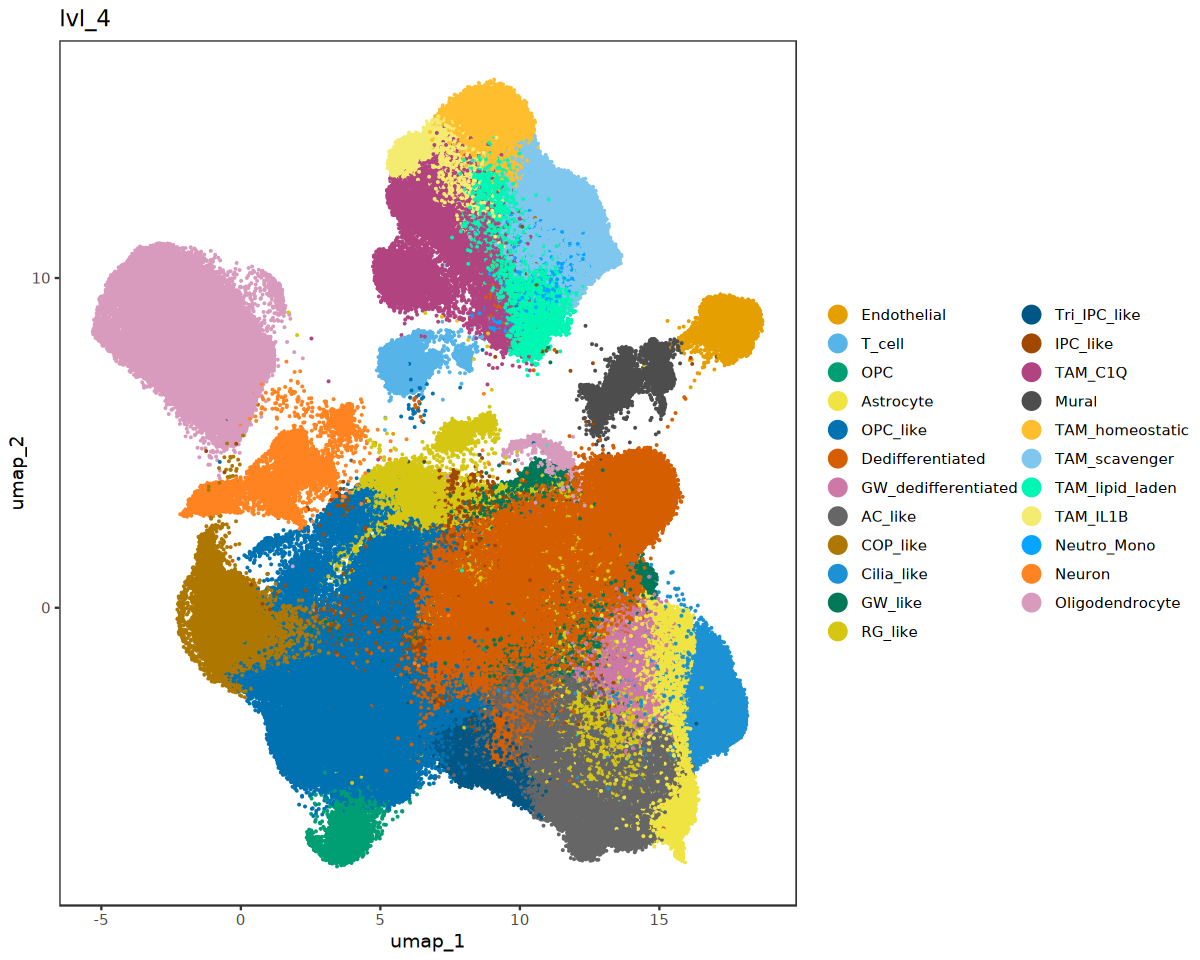

In [ ]:
options(repr.plot.height = 8, repr.plot.width = 10)
dittoDimPlot(dmg, 
             reduction.use = "umap", var = "lvl_4", 
             size = 0.5)

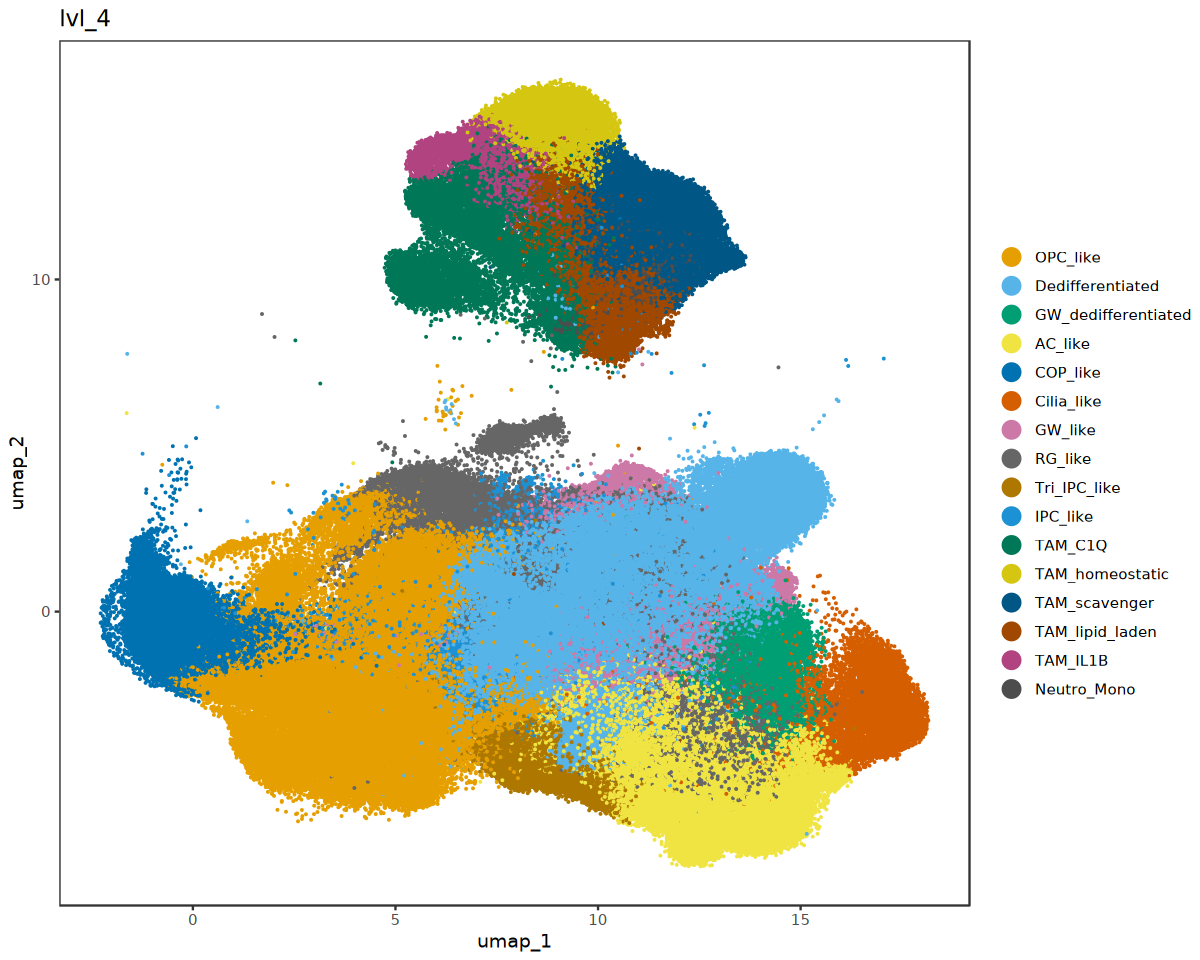

In [ ]:
dmg <-  subset(dmg, lvl_2 %in% c('Stem_like',
                                  'Differentiated_like',
                                  'Myeloid'))
dittoDimPlot(dmg, 
             reduction.use = "umap", var = "lvl_4", 
             size = 0.5)

In [ ]:
dmg$lvl_4 <- droplevels(recode(dmg$lvl_4,
                               'OPC_like'='opc.0', 
'COP_like'='cop.1', 
'TAM_scavenger'='scav.0', 
'Neutro_Mono'='neumono.1', 
'TAM_C1Q'='c1q.2', 
'TAM_lipid_laden'='lipid.3', 
'GW_like'='gw.2', 
'Dedifferentiated'='td.3', 
'IPC_like'='ipc.4', 
'GW_dedifferentiated'='gb.5', 
'AC_like'='ac.6', 
'Cilia_like'='cilia.7', 
'Tri_IPC_like'='tri.1', 
'RG_like'='rg.2', 
'TAM_homeostatic'='homeo.4', 
'TAM_IL1B'='il1b.5'            
))

In [ ]:
# Step 1: Identify unique values in the SampleID column
unique_sample_ids <- unique(dmg@meta.data$SampleID)

# Step 2: Generate new de-identified names
new_names <- paste0("projid.", seq_along(unique_sample_ids))

# Step 3: Replace original SampleID values with new de-identified names
for (i in seq_along(unique_sample_ids)) {
  dmg@meta.data$SampleID[dmg@meta.data$SampleID == unique_sample_ids[i]] <- new_names[i]
}

In [ ]:
data.frame(unique_sample_ids, new_names)

unique_sample_ids,new_names
<chr>,<chr>
BT042_PD,projid.1
BT042_pons_1,projid.2
BT042_pons_2,projid.3
BT072_region_1,projid.4
BT072_region_2,projid.5
BT789AAQ,projid.6
GNG_region_10,projid.7
GNG_region_11,projid.8
GNG_region_12,projid.9


##  Creating subpopulation proportion matrix

In [ ]:
df <- dmg@meta.data
df

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,⋯,predicted.annotation_level_4,iCNV,cell_id,lvl_0,lvl_1,lvl_2,lvl_3,lvl_4,lvl_5,lvl_4_coarse
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>,<fct>
BT042_PD_CCGTTCATCTATGTGG-1,10775,3338,10838,3366,Singlet,0.10909091,Singlet,0.66635233,T18-90532,projid.1,⋯,NPC-like Prolif,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_CTACCTGGTATGAAAC-1,9031,3613,9139,3644,Singlet,0.12727273,Singlet,0.66635233,T18-90532,projid.1,⋯,NPC-like Prolif,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_TTGCATTTCCTGTAGA-1,7641,2960,7697,2987,Singlet,0.10909091,Singlet,0.42149284,T18-90532,projid.1,⋯,OPC,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_GTGCTGGGTAACGCGA-1,7135,3151,7290,3183,Singlet,0.07272727,Doublet,0.98795068,T18-90532,projid.1,⋯,OPC,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like,OPC_like
BT042_PD_CTTCTAAAGACGCATG-1,5720,2362,5834,2405,Singlet,0.09090909,Singlet,0.33930978,T18-90532,projid.1,⋯,OPC,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_CCTCACACAAAGCTAA-1,5471,1911,5554,1948,Singlet,0.12727273,Singlet,0.31077635,T18-90532,projid.1,⋯,OPC-like,normal,Stem_like_normal,Neoplastic,Malignant,Differentiated_like,Oligodendroglial_fate,cop.1,COP_like,COP_like
BT042_PD_TGCGATAAGCCATCCG-1,4960,2065,4994,2080,Singlet,0.10909091,Singlet,0.76924258,T18-90532,projid.1,⋯,TAM-BDM anti-infl,normal,TAM_BDM,Non_neoplastic,Immune,Myeloid,MDM,scav.0,MDM_scavenger_stress,TAM_scavenger
BT042_PD_GAATAGAGTTTATGCG-1,4726,2219,4867,2231,Singlet,0.07272727,Singlet,0.24659014,T18-90532,projid.1,⋯,TAM-BDM anti-infl,normal,TAM_BDM,Non_neoplastic,Immune,Myeloid,MDM,scav.0,MDM_scavenger_stress,TAM_scavenger
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,4668,1824,Singlet,0.12727273,Singlet,0.08938396,T18-90532,projid.1,⋯,TAM-BDM anti-infl,normal,TAM_BDM,Non_neoplastic,Immune,Myeloid,MDM,scav.0,MDM_scavenger_stress,TAM_scavenger


In [ ]:
meta <- dmg@meta.data
meta

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,⋯,predicted.annotation_level_4,iCNV,cell_id,lvl_0,lvl_1,lvl_2,lvl_3,lvl_4,lvl_5,lvl_4_coarse
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>,<fct>
BT042_PD_CCGTTCATCTATGTGG-1,10775,3338,10838,3366,Singlet,0.10909091,Singlet,0.66635233,T18-90532,projid.1,⋯,NPC-like Prolif,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_CTACCTGGTATGAAAC-1,9031,3613,9139,3644,Singlet,0.12727273,Singlet,0.66635233,T18-90532,projid.1,⋯,NPC-like Prolif,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_TTGCATTTCCTGTAGA-1,7641,2960,7697,2987,Singlet,0.10909091,Singlet,0.42149284,T18-90532,projid.1,⋯,OPC,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_GTGCTGGGTAACGCGA-1,7135,3151,7290,3183,Singlet,0.07272727,Doublet,0.98795068,T18-90532,projid.1,⋯,OPC,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like,OPC_like
BT042_PD_CTTCTAAAGACGCATG-1,5720,2362,5834,2405,Singlet,0.09090909,Singlet,0.33930978,T18-90532,projid.1,⋯,OPC,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_CCTCACACAAAGCTAA-1,5471,1911,5554,1948,Singlet,0.12727273,Singlet,0.31077635,T18-90532,projid.1,⋯,OPC-like,normal,Stem_like_normal,Neoplastic,Malignant,Differentiated_like,Oligodendroglial_fate,cop.1,COP_like,COP_like
BT042_PD_TGCGATAAGCCATCCG-1,4960,2065,4994,2080,Singlet,0.10909091,Singlet,0.76924258,T18-90532,projid.1,⋯,TAM-BDM anti-infl,normal,TAM_BDM,Non_neoplastic,Immune,Myeloid,MDM,scav.0,MDM_scavenger_stress,TAM_scavenger
BT042_PD_GAATAGAGTTTATGCG-1,4726,2219,4867,2231,Singlet,0.07272727,Singlet,0.24659014,T18-90532,projid.1,⋯,TAM-BDM anti-infl,normal,TAM_BDM,Non_neoplastic,Immune,Myeloid,MDM,scav.0,MDM_scavenger_stress,TAM_scavenger
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,4668,1824,Singlet,0.12727273,Singlet,0.08938396,T18-90532,projid.1,⋯,TAM-BDM anti-infl,normal,TAM_BDM,Non_neoplastic,Immune,Myeloid,MDM,scav.0,MDM_scavenger_stress,TAM_scavenger


In [ ]:
df$class <- df$lvl_1
df$cell.type <- df$lvl_2
df$state <- df$lvl_4
df$grouping.by <- df$lvl_2
df$projid <- df$SampleID

In [ ]:
# Calculate participant-wise subpopulation-proportion (within cell-type)
df <- df %>% 
  count(class, grouping.by, cell.type, projid, state) %>%
  group_by(grouping.by, projid) %>%
  mutate(prevalence=n/sum(n)) %>%
  ungroup()
df

class,grouping.by,cell.type,projid,state,n,prevalence
<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<dbl>
Immune,Myeloid,Myeloid,projid.1,c1q.2,4,0.060606061
Immune,Myeloid,Myeloid,projid.1,scav.0,45,0.681818182
Immune,Myeloid,Myeloid,projid.1,lipid.3,10,0.151515152
Immune,Myeloid,Myeloid,projid.1,neumono.1,7,0.106060606
Immune,Myeloid,Myeloid,projid.10,c1q.2,2,0.007692308
Immune,Myeloid,Myeloid,projid.10,scav.0,210,0.807692308
Immune,Myeloid,Myeloid,projid.10,lipid.3,10,0.038461538
Immune,Myeloid,Myeloid,projid.10,il1b.5,1,0.003846154
Immune,Myeloid,Myeloid,projid.10,neumono.1,37,0.142307692


In [ ]:
proportions <- dcast(df, projid~state, value.var = "prevalence", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid")
proportions

,opc.0,td.3,gb.5,ac.6,cop.1,cilia.7,gw.2,rg.2,tri.1,ipc.4,c1q.2,homeo.4,scav.0,lipid.3,il1b.5,neumono.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
projid.1,1.000000000,0.000000000,0.0000000000,0.0000000000,0.9166666667,0.0000000000,0.083333333,0.0000000000,0.000000000,0.000000000,0.060606061,0.000000000,0.681818182,0.151515152,0.000000000,0.106060606
projid.10,0.997191011,0.152173913,0.2391304348,0.1739130435,0.3260869565,0.0326086957,0.000000000,0.0028089888,0.000000000,0.076086957,0.007692308,0.000000000,0.807692308,0.038461538,0.003846154,0.142307692
projid.11,0.861111111,0.788940810,0.0903426791,0.0132398754,0.0000000000,0.0000000000,0.078660436,0.1111111111,0.027777778,0.028816199,0.000000000,0.000000000,0.014657980,0.166123779,0.153094463,0.666123779
projid.12,0.915032680,0.210810811,0.0378378378,0.6540540541,0.0108108108,0.0000000000,0.048648649,0.0000000000,0.084967320,0.037837838,0.000000000,0.880000000,0.000000000,0.000000000,0.120000000,0.000000000
projid.13,0.910250354,0.358076564,0.0102707750,0.5420168067,0.0009337068,0.0032679739,0.048552754,0.0136986301,0.076051016,0.036881419,0.023310023,0.899766900,0.013986014,0.011655012,0.048951049,0.002331002
projid.14,0.988505747,0.154882155,0.0117845118,0.8181818182,0.0101010101,0.0000000000,0.000000000,0.0114942529,0.000000000,0.005050505,0.006076975,0.368669818,0.028359217,0.017555706,0.576637407,0.002700878
projid.15,0.986206897,0.119266055,0.0458715596,0.8211009174,0.0045871560,0.0000000000,0.000000000,0.0137931034,0.000000000,0.009174312,0.002702703,0.472972973,0.008108108,0.059459459,0.454954955,0.001801802
projid.16,0.930599369,0.047486034,0.1340782123,0.3882681564,0.0307262570,0.1145251397,0.189944134,0.0141955836,0.055205047,0.094972067,0.049771689,0.000000000,0.470319635,0.010502283,0.019178082,0.450228311
projid.17,0.987489575,0.008628955,0.0028763183,0.8379674017,0.0556088207,0.0019175455,0.001917546,0.0016680567,0.010842369,0.091083413,0.020942408,0.961605585,0.006980803,0.003490401,0.006980803,0.000000000


In [ ]:
counts <- dcast(df, projid~state, value.var = "n", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid")
counts

,opc.0,td.3,gb.5,ac.6,cop.1,cilia.7,gw.2,rg.2,tri.1,ipc.4,c1q.2,homeo.4,scav.0,lipid.3,il1b.5,neumono.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
projid.1,14,0,0,0,11,0,1,0,0,0,4,0,45,10,0,7
projid.10,355,14,22,16,30,3,0,1,0,7,2,0,210,10,1,37
projid.11,31,1013,116,17,0,0,101,4,1,37,0,0,9,102,94,409
projid.12,140,39,7,121,2,0,9,0,13,7,0,22,0,0,3,0
projid.13,1927,767,22,1161,2,7,104,29,161,79,10,386,6,5,21,1
projid.14,86,92,7,486,6,0,0,1,0,3,9,546,42,26,854,4
projid.15,143,26,10,179,1,0,0,2,0,2,3,525,9,66,505,2
projid.16,590,17,48,139,11,41,68,9,35,34,109,0,1030,23,42,986
projid.17,2368,9,3,874,58,2,2,4,26,95,12,551,4,2,4,0


In [ ]:
ids <- rownames(proportions)
data <- AnnData(
  # Subpopulation proportions: participants (rows) over subpopulations (columns)
  X = proportions,
  
  # Counts and sqrt(prop) of subpopulations
  layers = list(counts = counts[ids, colnames(proportions)],
                sqrt.prev = sqrt(proportions)),
  
  # General information about the different subpopulations
  var = df %>% dplyr::select(class, grouping.by, cell.type, state) %>% unique %>% column_to_rownames("state") %>% `[`(colnames(proportions),),
  
  # # General information about the participants
  # obs = list(batches = df_summary[ids,])
)

In [ ]:
data

AnnData object with n_obs × n_vars = 83 × 16
    var: 'class', 'grouping.by', 'cell.type'
    layers: 'counts', 'sqrt.prev'

In [ ]:
cell.type.df <- df %>% group_by(projid, class, cell.type) %>%
  dplyr::summarise(n = sum(n), .groups = "drop") %>%
  dplyr::group_by(projid) %>%
  dplyr::mutate(prevalence = n/sum(n)) %>%
  dplyr::group_by(projid, class) %>%
  dplyr::mutate(within.class.prevalence = n/sum(n))

In [ ]:
ct.counts <- (dcast(cell.type.df, projid~cell.type, value.var = "n", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid"))[data$obs_names, ]
ct.prev   <- (dcast(cell.type.df, projid~cell.type, value.var = "prevalence", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid"))[data$obs_names, ]
ct.c.prev <- (dcast(cell.type.df, projid~cell.type, value.var = "within.class.prevalence", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid"))[data$obs_names, ]

In [ ]:
data$uns$cell.types <- list(counts = ct.counts, 
                            prev = ct.prev, 
                            sqrt.prev = sqrt(ct.prev), 
                            wc.prev = ct.c.prev, 
                            sqrt.wc.prev = sqrt(ct.c.prev))

In [ ]:
meta <- dmg@meta.data
meta

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,⋯,predicted.annotation_level_4,iCNV,cell_id,lvl_0,lvl_1,lvl_2,lvl_3,lvl_4,lvl_5,lvl_4_coarse
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>,<fct>
BT042_PD_CCGTTCATCTATGTGG-1,10775,3338,10838,3366,Singlet,0.10909091,Singlet,0.66635233,T18-90532,projid.1,⋯,NPC-like Prolif,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_CTACCTGGTATGAAAC-1,9031,3613,9139,3644,Singlet,0.12727273,Singlet,0.66635233,T18-90532,projid.1,⋯,NPC-like Prolif,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_TTGCATTTCCTGTAGA-1,7641,2960,7697,2987,Singlet,0.10909091,Singlet,0.42149284,T18-90532,projid.1,⋯,OPC,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_GTGCTGGGTAACGCGA-1,7135,3151,7290,3183,Singlet,0.07272727,Doublet,0.98795068,T18-90532,projid.1,⋯,OPC,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like,OPC_like
BT042_PD_CTTCTAAAGACGCATG-1,5720,2362,5834,2405,Singlet,0.09090909,Singlet,0.33930978,T18-90532,projid.1,⋯,OPC,normal,Stem_like_normal,Neoplastic,Malignant,Stem_like,Stem_intermediate,opc.0,OPC_like_proliferating,OPC_like
BT042_PD_CCTCACACAAAGCTAA-1,5471,1911,5554,1948,Singlet,0.12727273,Singlet,0.31077635,T18-90532,projid.1,⋯,OPC-like,normal,Stem_like_normal,Neoplastic,Malignant,Differentiated_like,Oligodendroglial_fate,cop.1,COP_like,COP_like
BT042_PD_TGCGATAAGCCATCCG-1,4960,2065,4994,2080,Singlet,0.10909091,Singlet,0.76924258,T18-90532,projid.1,⋯,TAM-BDM anti-infl,normal,TAM_BDM,Non_neoplastic,Immune,Myeloid,MDM,scav.0,MDM_scavenger_stress,TAM_scavenger
BT042_PD_GAATAGAGTTTATGCG-1,4726,2219,4867,2231,Singlet,0.07272727,Singlet,0.24659014,T18-90532,projid.1,⋯,TAM-BDM anti-infl,normal,TAM_BDM,Non_neoplastic,Immune,Myeloid,MDM,scav.0,MDM_scavenger_stress,TAM_scavenger
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,4668,1824,Singlet,0.12727273,Singlet,0.08938396,T18-90532,projid.1,⋯,TAM-BDM anti-infl,normal,TAM_BDM,Non_neoplastic,Immune,Myeloid,MDM,scav.0,MDM_scavenger_stress,TAM_scavenger


In [ ]:
df_summary <- meta %>%
  group_by(SampleID) %>%
  summarize(
    Study = first(Study),
    Preservation_method = first(Preservation_method),
    Diagnosis = first(Diagnosis),
    Tumor_type = first(Tumor_type),
    Tumor_subtype = first(Tumor_subtype),
    Location = first(Location),
    Source = first(Source),
    Clinical_status = first(Clinical_status),
    Paired_sample = first(Paired_sample),
    Multisector = first(Multisector),
    Gender = first(Gender),
    Age_years = mean(Age_years, na.rm = TRUE),
    Dexamethasone_prior_surgery = first(Dexamethasone_prior_surgery)
  ) %>% column_to_rownames("SampleID")
df_summary

Warning message:
“There were 83 warnings in `summarize()`.
The first warning was:
ℹ In argument: `Age_years = mean(Age_years, na.rm = TRUE)`.
ℹ In group 1: `SampleID = "projid.1"`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 82 remaining warnings.”


,Study,Preservation_method,Diagnosis,Tumor_type,Tumor_subtype,Location,Source,Clinical_status,Paired_sample,Multisector,Gender,Age_years,Dexamethasone_prior_surgery
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
projid.1,Ruiz2023,Cryo,DMG Pons,DMG H3 K27-altered,H3.1 K27-mutant,Pons,Autopsy,Recurrence,N,Y,F,NA,No
projid.10,Ruiz2023,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Autopsy,Recurrence,N,Y,M,NA,Yes
projid.11,Ruiz2023,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,N,N,F,NA,Yes
projid.12,Ruiz2023,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,N,N,F,NA,No
projid.13,Ruiz2023,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,N,N,F,NA,No
projid.14,Ruiz2023,Cryo,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,N,Y,M,NA,Yes
projid.15,Ruiz2023,Cryo,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,N,Y,M,NA,Yes
projid.16,Ruiz2023,Cryo,DMG Spinal,DMG H3 K27-altered,H3.3 K27-mutant,Spinal,Biopsy,Primary,N,N,F,NA,Yes
projid.17,Ruiz2023,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.1 K27-mutant,Pons,Biopsy,Primary,N,N,M,NA,No


In [ ]:
# Assuming df_summary is your summarized dataframe in R
pd <- import("pandas")  # Import pandas module
df_summary_py <- r_to_py(df_summary)  # Convert R dataframe to pandas dataframe

In [ ]:
# Assign the df_summary_py to the .obs attribute of the AnnData object
data$obs <- df_summary_py

## Creating cellular landscape representation

In [ ]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/utils.R")

In [ ]:
sc <- reticulate::import("scanpy")

In [ ]:
# Participant clustering based on cellular environment representation
sc$pp$neighbors(data, n_neighbors = as.integer(10), use_rep = "X", metric = "cosine")
sc$tl$leiden(data, resolution =.25)
sc$tl$leiden(data, resolution = .75, restrict_to=reticulate::tuple("leiden", reticulate::np_array(c("0"))))
data$obs["clusters"] = plyr::mapvalues(data$obs$leiden_R, levels(data$obs$leiden_R), 1:length(levels(data$obs$leiden_R)))
data$obs$leiden <- data$obs$leiden_R <- NULL

In [ ]:
# 2D visualization of landscape
sc$tl$tsne(data, n_pcs = 0, use_rep = "X", learning_rate = 100)
sc$tl$umap(data, maxiter = as.integer(3000), spread = 3)

In [ ]:
# Compute PHATE embedding for all donors
sc$external$tl$phate(data, 
                     n_components = as.integer(3),  
                     k = as.integer(10), a = as.integer(40), 
                     knn_dist =  "euclidean", mds_dist = "euclidean", 
                     mds_solver = "smacof", verbose = F)
data$obsm$X_all_3d_phate <- data$obsm$X_phate
data$obsm$X_phate <- NULL

In [ ]:
data

AnnData object with n_obs × n_vars = 83 × 16
    obs: 'clusters'
    var: 'class', 'grouping.by', 'cell.type'
    uns: 'cell.types', 'neighbors', 'leiden', 'leiden_R', 'tsne', 'umap', 'trajectories'
    obsm: 'X_tsne', 'X_umap', 'X_all_3d_phate'
    layers: 'counts', 'sqrt.prev'
    obsp: 'similarity_X_all_3d_phate', 'similarity_X_umap', 'similarity_X_tsne'

In [ ]:
# Local similarities of participants based on cellular environments
data$obsp <- list()
for(e in c("X_all_3d_phate","X_umap","X_tsne")) 
  data$obsp[[paste0("similarity_", e)]] <- embedding.similarity(data$obsm[[e]], knn = 5)
anndata::write_h5ad(data, "../data/beyond/subpopulation.proportions.h5ad")

In [ ]:
data

AnnData object with n_obs × n_vars = 83 × 16
    obs: 'Study', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'clusters'
    var: 'class', 'grouping.by', 'cell.type'
    uns: 'cell.types', 'neighbors', 'leiden', 'leiden_R', 'tsne', 'umap', 'trajectories'
    obsm: 'X_tsne', 'X_umap', 'X_all_3d_phate'
    layers: 'counts', 'sqrt.prev'
    obsp: 'similarity_X_all_3d_phate', 'similarity_X_umap', 'similarity_X_tsne', 'distances', 'connectivities'

In [ ]:
anndata::write_h5ad(data, "../data/beyond/subpopulation.proportions.h5ad")